In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('Telco-Customer-Churn.csv')
print(f"Dataset loaded. Shape: {df.shape}")
df.head()

Dataset loaded. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
missing_charges = df[df['TotalCharges'].str.strip() == '']
print(f"Rows with blank TotalCharges: {len(missing_charges)}")
missing_charges[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Rows with blank TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

print(df['TotalCharges'].dtypes)
print("Remaining missing values:", df['TotalCharges'].isna().sum())

float64
Remaining missing values: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proportions:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


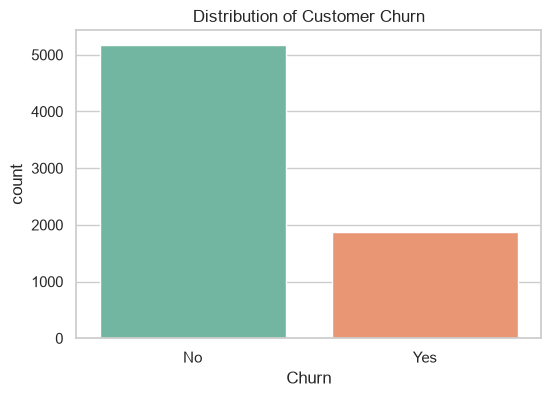

In [5]:
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(df['Churn'].value_counts())
print("\nProportions:")
print(churn_pct)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribution of Customer Churn')
plt.show()

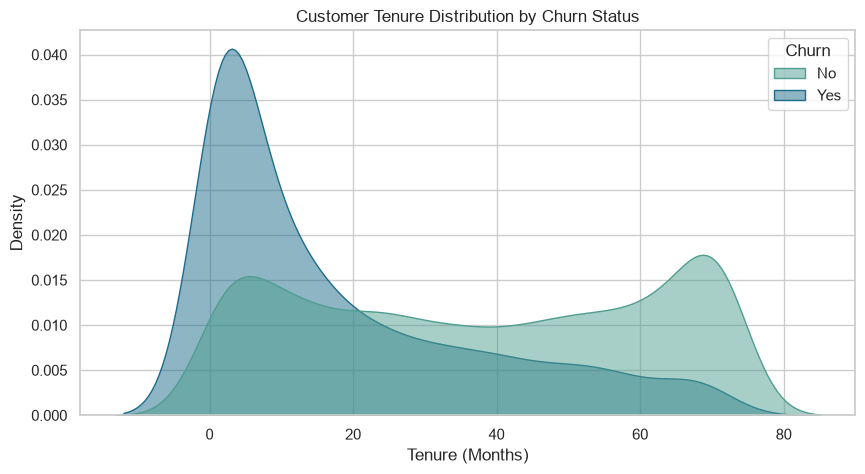

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Customer Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.show()

Churn Rate by Contract Type (%):
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


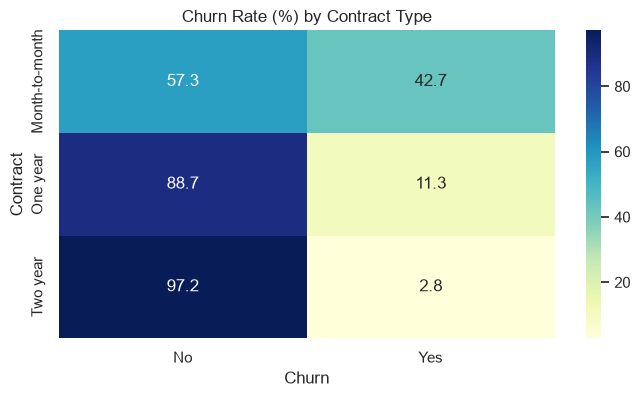

In [7]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print("Churn Rate by Contract Type (%):")
print(contract_churn)

plt.figure(figsize=(8, 4))
sns.heatmap(contract_churn, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Churn Rate (%) by Contract Type')
plt.show()

In [8]:
support_churn = pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100
print("Churn Rate by Tech Support Availability (%):")
print(support_churn)

Churn Rate by Tech Support Availability (%):
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341
